In [1]:
using Plots

using PyCall
@pyimport umap as umap;

include("../src/fxio.jl")
include("../src/kabsch_umeyama.jl")

/usr/local/Anaconda/envs/py3.9/lib/python3.9/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/usr/local/Anaconda/envs/py3.9/lib/python3.9/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/usr/local/Anaconda/envs/py3.9/lib/python3.9/site-packages/umap/distances.py:108

fxity_kabsh (generic function with 2 methods)

In [3]:
f = open("../data/dssp.csv") 
dssp = Dict()
for line in readlines(f) 
    key_seq = split(line, ",")
    dssp[key_seq[1]] = key_seq[2]
end

In [6]:
function convertdssp(dssp4mer)

    for i in 1:length(dssp4mer)
        if contains(dssp4mer[i], "HHH")
            dssp4mer[i] = "red"
        elseif  contains(dssp4mer[i], "EE")
            dssp4mer[i] = "blue"
        elseif  contains(dssp4mer[i], "TT")
            dssp4mer[i] = "green"
        else 
            dssp4mer[i] = "gray"
        end
    end
    
    return dssp4mer
end

function pdb2vtors(pdbpath)
    seqxyz = pdb2seqxyz(pdbpath)
    kmers = coords2kmers(seqxyz, 4, "ca")

    vtors = zeros(Float64, length(kmers), 3)
    
    for (i, kmer) in enumerate(kmers)
        vtors[i,1:3] = vtor(kmer[:,2:4])
    end
    
    return vtors
end


pdb2vtors (generic function with 1 method)

In [7]:
scoppath = "../../scop40NR/" 
virtual_torsions = reshape(Float64[], 0, 3)
sscolors = []
for pdb in readdir(scoppath)

    try
        pdbpath = joinpath(scoppath, pdb)
        id = basename(pdbpath)[1:end-4]
        dsspcolors = convertdssp(seq2kmers(dssp[id], 4))
        vtors = pdb2vtors(pdbpath)   
        if (size(vtors, 1) == length(dsspcolors)) 
            if !any(isnan.(vtors))
            virtual_torsions = vcat(virtual_torsions, vtors)
            sscolors = vcat(sscolors, dsspcolors)
            end
        end
    catch

        println(pdb)#, " ", size(vtors, 1), " ", length(dsspcolors))
    
    end
end

println(size(virtual_torsions, 1))
println(length(sscolors))

d1qcrd2.ent
d4cpai_.ent
353693
353693


In [8]:
range = 1:10000
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.01, n_epochs=200)[:fit_transform](permutedims(virtual_torsions[range,:]')) 
print(size(umap_model))

(10000, 2)

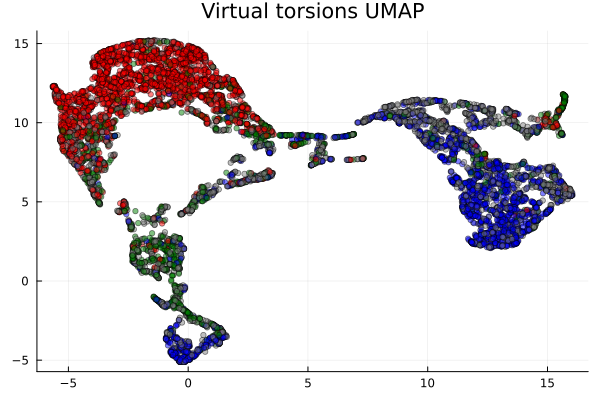

In [19]:
scatter(umap_model[:,1], umap_model[:,2], color=sscolors[range], 
    title="Virtual torsions UMAP", labels=false,
    markersize=3, alpha=0.5)

In [ ]:
using PlotlyJS

vtors = hcat(sscolors, virtual_torsions)[1:1000,:]

function vtor_vectors(seqxyz)

    colors = seqxyz[:, 1]  # Colors (String)
    X = seqxyz[:, 2]  # X-coordinates (Float64)
    Y = seqxyz[:, 3]  # Y-coordinates (Float64)
    Z = seqxyz[:, 4]  # Z-coordinates (Float64)


    traces = Vector{GenericTrace}()  # Correctly define traces as a vector of GenericTrace

    for i in eachindex(X)
        push!(traces, PlotlyJS.scatter3d(
            x=[0, X[i]],  # Connect (0,0,0) to (X, Y, Z)
            y=[0, Y[i]],
            z=[0, Z[i]],
            mode="lines+markers",
            marker=attr(size=1, color=colors[i]),  # Set marker color
            line=attr(width=0.1, color=colors[i])  # Set line color
        ))
    end
        
    layout = Layout(
            title="v-tors vectors",
            width=800,    # Set plot width
            height=600,   # Set plot height
            scene=attr(
                xaxis=attr(visible=true, title="\nDihedral"),
                yaxis=attr(visible=true, title="Angle1"),
                zaxis=attr(visible=true, title="Angle2"), 
                camera=attr(
                projection=attr(type="orthographic")  # Set perspective view
                )
            )
        )

    return PlotlyJS.plot(traces, layout)
end

vtor_vectors(vtors)